# Day 6: Pressure Prediction Baseline

Extends the Day 5 MLP (Cl + Cd) to predict the full pressure coefficient distribution (Cp) alongside Cl and Cd.

**Inputs:** Airfoil Geometry (198) + AoA + Reynolds + Ncrit = 201  
**Outputs:** Cl + Cd + Cp (98) = 100  

Day 5 artifacts (`baseline_mlp.pt`, `baseline_metrics.json`) are preserved and not overwritten.

In [1]:
!wget https://nasa-public-data.s3.amazonaws.com/plot3d_utilities/dataset-processed.zip
!unzip dataset-processed.zip


!python preprocess_airfoil_dataset.py \
    --input_dir datasets/standard \
    --output_dir processed_output \
    --scaler_name standard

--2026-06-22 15:16:01--  https://nasa-public-data.s3.amazonaws.com/plot3d_utilities/dataset-processed.zip
Resolving nasa-public-data.s3.amazonaws.com (nasa-public-data.s3.amazonaws.com)... 16.182.37.1, 16.15.237.156, 54.231.195.57, ...
Connecting to nasa-public-data.s3.amazonaws.com (nasa-public-data.s3.amazonaws.com)|16.182.37.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9188863364 (8.6G) [application/zip]
Saving to: ‘dataset-processed.zip’

dataset-processed.z 100%[===================>]   8.56G  27.1MB/s    in 5m 21s  

2026-06-22 15:21:22 (27.3 MB/s) - ‘dataset-processed.zip’ saved [9188863364/9188863364]

Archive:  dataset-processed.zip
   creating: datasets/
   creating: datasets/minmax/
  inflating: datasets/minmax/dnn_scaled_data_cp_test.pt  
  inflating: datasets/minmax/dnn_scaled_data_cp_train.pt  
  inflating: datasets/minmax/dnn_scaled_data_test.pt  
  inflating: datasets/minmax/dnn_scaled_data_train.pt  
  inflating: datasets/minmax/graph_scal

In [2]:
import numpy as np

train = np.load("processed_output/standard/main/train.npz")
val   = np.load("processed_output/standard/main/val.npz")
test  = np.load("processed_output/standard/main/test.npz")

print("Train samples:", train["cl"].shape[0])
print("Val   samples:", val["cl"].shape[0])
print("Test  samples:", test["cl"].shape[0])

Train samples: 457283
Val   samples: 80696
Test  samples: 230563


In [3]:
# Build feature matrices — same as Day 5
def make_X(split):
    return np.hstack([
        split["geometry_y"],
        split["alpha"].reshape(-1, 1),
        split["reynolds"].reshape(-1, 1),
        split["ncrit"].reshape(-1, 1)
    ])

# Updated target: Cl + Cd + Cp (100 outputs)
def make_y(split):
    return np.concatenate([
        split["cl"].reshape(-1, 1),
        split["cd"].reshape(-1, 1),
        split["cp"]
    ], axis=1)

X_train = make_X(train);  y_train = make_y(train)
X_val   = make_X(val);    y_val   = make_y(val)
X_test  = make_X(test);   y_test  = make_y(test)

print("X_train:", X_train.shape)  # (N, 201)
print("y_train:", y_train.shape)  # (N, 100)

X_train: (457283, 201)
y_train: (457283, 100)


In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader

def to_loader(X, y, batch_size=1024, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader   = to_loader(X_val,   y_val,   shuffle=False)

In [5]:
import torch.nn as nn

class MLP(nn.Module):
    """
    Same architecture as Day 5 except output layer is 100 (Cl + Cd + Cp[98])
    instead of 2 (Cl + Cd only).
    """
    def __init__(self, out_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(201, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, out_dim)
        )

    def forward(self, x):
        return self.net(x)

model = MLP(out_dim=100).cuda()
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=201, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=100, bias=True)
  )
)


In [6]:
# ── Weighted loss ──────────────────────────────────────────────────────────
# Each of the 100 outputs gets a per-output weight stored in a 1-D tensor.
#
#   w_coeff  : weight applied to EACH of the 2 scalar outputs (Cl, Cd)
#   w_cp     : weight applied to EACH of the 98 Cp outputs
#
# Setting w_coeff = 49 and w_cp = 1 gives the two coefficients a combined
# contribution equal to the entire Cp block  (2×49 = 98×1 = 98 units each),
# so neither group dominates the gradient signal.
#
# Adjust freely — raise w_coeff if Cl/Cd still lag, or raise w_cp if you
# want to push harder on the pressure shape.

W_COEFF = 49.0   # weight per coefficient output  (Cl, Cd)
W_CP    = 1.0    # weight per Cp output           (98 channels)

output_weights = torch.tensor(
    [W_COEFF, W_COEFF] + [W_CP] * 98,
    dtype=torch.float32
).cuda()  # shape: (100,)


def weighted_mse(pred, target, weights):
    """
    Weighted MSE loss.

    Args:
        pred    : (B, 100)
        target  : (B, 100)
        weights : (100,)   — per-output weights

    Returns scalar loss.  Weights are normalised inside so the absolute
    magnitude stays comparable to the old unweighted MSE.
    """
    sq_err = (pred - target) ** 2          # (B, 100)
    w_norm = weights / weights.sum()       # sum-to-1 normalisation
    return (sq_err * w_norm).sum(dim=1).mean()


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
best_val_loss = float("inf")

for epoch in range(20):
    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for x, y in train_loader:
        x, y = x.cuda(), y.cuda()
        optimizer.zero_grad()
        loss = weighted_mse(model(x), y, output_weights)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    # ── Validate ─────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.cuda(), y.cuda()
            val_loss += weighted_mse(model(x), y, output_weights).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1:02d} | Train Loss = {train_loss:.6f} | Val Loss = {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "weighted_cl_cd_cp.pt")

print("\nTraining complete. Best Val Loss:", best_val_loss)


Epoch 01 | Train Loss = 0.611239 | Val Loss = 0.521606
Epoch 02 | Train Loss = 0.542623 | Val Loss = 0.505414
Epoch 03 | Train Loss = 0.532040 | Val Loss = 0.500906
Epoch 04 | Train Loss = 0.522112 | Val Loss = 0.489763
Epoch 05 | Train Loss = 0.515000 | Val Loss = 0.490968
Epoch 06 | Train Loss = 0.504210 | Val Loss = 0.492004
Epoch 07 | Train Loss = 0.498636 | Val Loss = 0.446550
Epoch 08 | Train Loss = 0.507632 | Val Loss = 0.442146
Epoch 09 | Train Loss = 0.474817 | Val Loss = 0.376399
Epoch 10 | Train Loss = 0.361973 | Val Loss = 0.231601
Epoch 11 | Train Loss = 0.314700 | Val Loss = 0.200977
Epoch 12 | Train Loss = 0.258711 | Val Loss = 0.173418
Epoch 13 | Train Loss = 0.151660 | Val Loss = 0.224329
Epoch 14 | Train Loss = 0.132690 | Val Loss = 0.097442
Epoch 15 | Train Loss = 0.109402 | Val Loss = 0.479085
Epoch 16 | Train Loss = 0.209192 | Val Loss = 0.087943
Epoch 17 | Train Loss = 0.106775 | Val Loss = 0.100521
Epoch 18 | Train Loss = 0.075144 | Val Loss = 0.114015
Epoch 19 |

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import json

# Load best weighted checkpoint
model.load_state_dict(torch.load("weighted_cl_cd_cp.pt"))
model.eval()

X_val_t = torch.tensor(X_val, dtype=torch.float32).cuda()
with torch.no_grad():
    pred = model(X_val_t).cpu().numpy()

# Slice outputs
pred_cl = pred[:, 0];   true_cl = y_val[:, 0]
pred_cd = pred[:, 1];   true_cd = y_val[:, 1]
pred_cp = pred[:, 2:];  true_cp = y_val[:, 2:]

# ── Overall (unweighted for comparability with Day 6) ────────────────────
overall_mae  = mean_absolute_error(y_val, pred)
overall_rmse = np.sqrt(mean_squared_error(y_val, pred))
overall_r2   = r2_score(y_val, pred)

# ── Per-target ────────────────────────────────────────────────────────────
cl_mae  = mean_absolute_error(true_cl, pred_cl)
cl_rmse = np.sqrt(mean_squared_error(true_cl, pred_cl))
cl_r2   = r2_score(true_cl, pred_cl)

cd_mae  = mean_absolute_error(true_cd, pred_cd)
cd_rmse = np.sqrt(mean_squared_error(true_cd, pred_cd))
cd_r2   = r2_score(true_cd, pred_cd)

cp_mae  = mean_absolute_error(true_cp, pred_cp)
cp_rmse = np.sqrt(mean_squared_error(true_cp, pred_cp))
cp_r2   = r2_score(true_cp, pred_cp)

print(f"Overall  | MAE={overall_mae:.6f}  RMSE={overall_rmse:.6f}  R²={overall_r2:.4f}")
print(f"Cl       | MAE={cl_mae:.6f}  RMSE={cl_rmse:.6f}  R²={cl_r2:.4f}")
print(f"Cd       | MAE={cd_mae:.6f}  RMSE={cd_rmse:.6f}  R²={cd_r2:.4f}")
print(f"Cp       | MAE={cp_mae:.6f}  RMSE={cp_rmse:.6f}  R²={cp_r2:.4f}")

metrics = {
    "loss_weights": {"w_coeff": W_COEFF, "w_cp": W_CP},
    "overall_mae":  overall_mae,
    "overall_rmse": overall_rmse,
    "overall_r2":   overall_r2,
    "cl_mae":  cl_mae,  "cl_rmse":  cl_rmse,  "cl_r2":  cl_r2,
    "cd_mae":  cd_mae,  "cd_rmse":  cd_rmse,  "cd_r2":  cd_r2,
    "cp_mae":  cp_mae,  "cp_rmse":  cp_rmse,  "cp_r2":  cp_r2,
}

with open("weighted_cl_cd_cp_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("\nMetrics saved to weighted_cl_cd_cp_metrics.json")


Overall  | MAE=0.033814  RMSE=0.258181  R²=0.8409
Cl       | MAE=0.089990  RMSE=0.127626  R²=0.9836
Cd       | MAE=0.174542  RMSE=0.292603  R²=0.9139
Cp       | MAE=0.031804  RMSE=0.258801  R²=0.8387

Metrics saved to weighted_cl_cd_cp_metrics.json


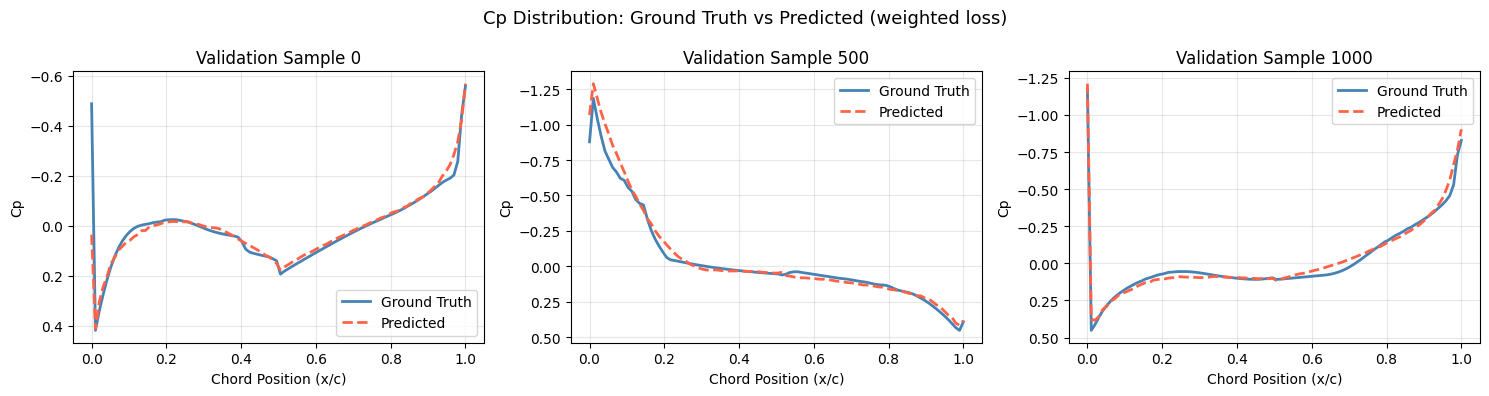

Saved: cp_comparison_weighted.png


In [8]:
import matplotlib.pyplot as plt

# Plot Cp ground truth vs prediction for 3 validation samples
sample_indices = [0, 500, 1000]
x_surface = np.linspace(0, 1, 98)  # normalised chord position

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, idx in enumerate(sample_indices):
    ax = axes[i]
    ax.plot(x_surface, true_cp[idx], label="Ground Truth", color="steelblue", linewidth=2)
    ax.plot(x_surface, pred_cp[idx], label="Predicted",    color="tomato",    linewidth=2, linestyle="--")
    ax.invert_yaxis()  # Cp convention: lower values plotted upward
    ax.set_xlabel("Chord Position (x/c)")
    ax.set_ylabel("Cp")
    ax.set_title(f"Validation Sample {idx}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Cp Distribution: Ground Truth vs Predicted (weighted loss)", fontsize=13)
plt.tight_layout()
plt.savefig("cp_comparison_weighted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cp_comparison_weighted.png")
